In [1]:
from halotools.sim_manager import DownloadManager
dman = DownloadManager()
dman.download_processed_halo_table(
    "multidark",
    "rockstar",
    0.0,
    overwrite=True
)


... Downloading data from the following location: 
http://www.astro.yale.edu/aphearin/Data_files/halo_catalogs/multidark/rockstar/hlist_1.00109.list.halotools_v0p4.hdf5

 ... Saving the data with the following filename: 
/Users/naigezhang/.astropy/cache/halotools/halo_catalogs/multidark/rockstar/hlist_1.00109.list.halotools_v0p4.hdf5

5% complete, elapsed time = 68 seconds
10% complete, elapsed time = 149 seconds
15% complete, elapsed time = 224 seconds
20% complete, elapsed time = 305 seconds
25% complete, elapsed time = 375 seconds
30% complete, elapsed time = 457 seconds
35% complete, elapsed time = 527 seconds
40% complete, elapsed time = 606 seconds
45% complete, elapsed time = 684 seconds
50% complete, elapsed time = 768 seconds
55% complete, elapsed time = 843 seconds
60% complete, elapsed time = 926 seconds
65% complete, elapsed time = 1002 seconds
70% complete, elapsed time = 1070 seconds
75% complete, elapsed time = 1138 seconds
80% complete, elapsed time = 1216 seconds
85% 

In [2]:
from halotools.sim_manager import CachedHaloCatalog
halocat = CachedHaloCatalog(
    simname="multidark",
    halo_finder="rockstar",
    version_name="halotools_v0p4",
    redshift=-0.0011
)
halos = halocat.halo_table

In [3]:
print("sim name:",halocat.simname)
# print("halo finder:",halocat.halo_finder)
# print("redshift:",halocat.redshift)
print("size:",halocat.Lbox)
# print("particle mass:",halocat.particle_mass)

sim name: b'multidark'
size: [1000. 1000. 1000.]


In [4]:
halos = halocat.halo_table
print("number of halos:",len(halos))
# print(halos.colnames)# 

number of halos: 1709942


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Corrfunc.theory.xi import xi
x = np.array(halos["halo_x"])
y = np.array(halos["halo_y"])
z = np.array(halos["halo_z"])
m = np.array(halos["halo_mvir"])
halos = pd.DataFrame({
    "x": x,
    "y": y,
    "z": z,
    "m": m
})
halos.head()


,x,y,z,m
0,143.717514,168.869568,78.237823,1.625000e+15
1,178.742630,181.869217,172.080521,1.022000e+15
2,90.020203,53.280182,34.724529,9.895000e+14
3,41.624050,239.425674,158.684311,8.718000e+14
4,229.002548,141.883865,13.504650,8.086000e+14


In [6]:
size = (float)(halocat.Lbox[0]) #simulation box size
n = len(halos)
m_threshold = 1e14 #1/h solar masses

#Corrfunc
rmin = 20 #20-200 # Mpc/h, min separation distance i will consider
rmax = min(200, size / 2 - 1)
# print(rmax)
nbins = 30 #dividing range into intervals
rbins = np.linspace(rmin,rmax,nbins+1)

# BAO region
bao_min = 50 #Mpc/h
bao_max = 150




In [7]:
filtered = halos[halos["m"] > m_threshold].copy()
N_filtered = len(filtered)
V = size**3
rho_N = N_filtered / V
mean_m = filtered["m"].mean()
print("Number density of halos",rho_N)
print("Mean halo mass",mean_m)
filtered.head()

Number density of halos 2.0528e-05
Mean halo mass 2.0057796e+14


,x,y,z,m
0,143.717514,168.869568,78.237823,1.625000e+15
1,178.742630,181.869217,172.080521,1.022000e+15
2,90.020203,53.280182,34.724529,9.895000e+14
3,41.624050,239.425674,158.684311,8.718000e+14
4,229.002548,141.883865,13.504650,8.086000e+14


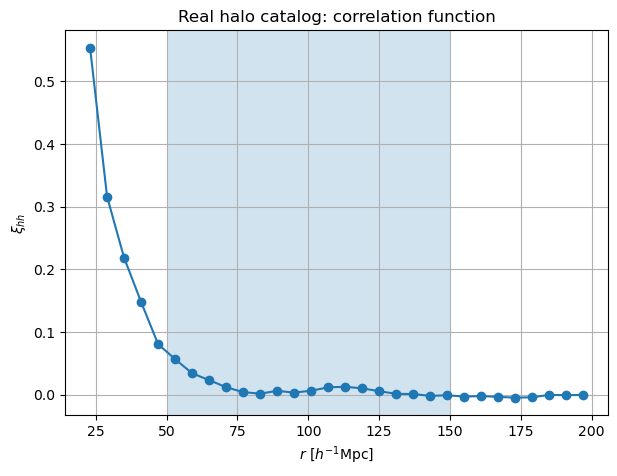

In [10]:
#corr
results = xi(boxsize=size,nthreads=4,binfile=rbins,X=filtered["x"].values,Y=filtered["y"].values,Z=filtered["z"].values)
results[:5]
o = 0.5 * (results["rmin"]+results["rmax"]) #origin
xi = results["xi"]
plt.figure(figsize=(7, 5))
plt.plot(o, xi, marker="o")
plt.axvspan(bao_min, bao_max, alpha=0.2)
plt.xlabel(r"$r\ [h^{-1}\mathrm{Mpc}]$")
plt.ylabel(r"$\xi_{hh}(r)$")
plt.title("Real halo catalog: correlation function")
plt.grid(True)
plt.show()